# Refactored SMAC x^2 experiment
This notebook consolidates imports, wraps logic in functions, and provides clearer, repeatable plotting steps.

In [1]:
# Consolidated imports and constants
from ConfigSpace import ConfigurationSpace, Float
from smac import Scenario, BlackBoxFacade
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

SEED = 67
N_TRIALS = 20

In [2]:
# Target function and setup helpers
def target_function(config, seed=SEED):
    x = config['x']
    return x**2

def make_configspace(seed=SEED):
    cs = ConfigurationSpace(seed=seed)
    f = Float(name='x', bounds=(-10, 10))
    cs.add(f)
    return cs

def setup_smac(n_trials=N_TRIALS, seed=SEED):
    cs = make_configspace(seed)
    scenario = Scenario(name='x_squared_basic', configspace=cs, deterministic=True, n_trials=n_trials, seed=seed)
    smac = BlackBoxFacade(scenario=scenario, target_function=target_function)
    return smac

In [3]:
# Run the optimization (single, deterministic run)
smac = setup_smac()
incumbent = smac.optimize()
print('Best found configuration:', incumbent)

[INFO][abstract_initial_design.py:91] Reducing the number of initial configurations from 8 to 5 (max_ratio == 0.25).
[INFO][abstract_initial_design.py:143] Using 5 initial design configurations and 0 additional configurations.
[INFO][smbo.py:523] Continuing from previous run.
[INFO][smbo.py:280] Optimization process was already finished. Returning incumbent...
Best found configuration: Configuration(values={
  'x': -7.08859983e-05,
})


In [4]:
# Basic runhistory summary with safety checks
rh = smac.runhistory
print('Trials in runhistory:', len(rh))
try:
    incumbent_cost = rh.average_cost(incumbent)
except Exception:
    try:
        incumbent_cost = rh.get_cost(incumbent)
    except Exception:
        incumbent_cost = None
print('Incumbent cost:', incumbent_cost)

Trials in runhistory: 20
Incumbent cost: 5.024824754987602e-09


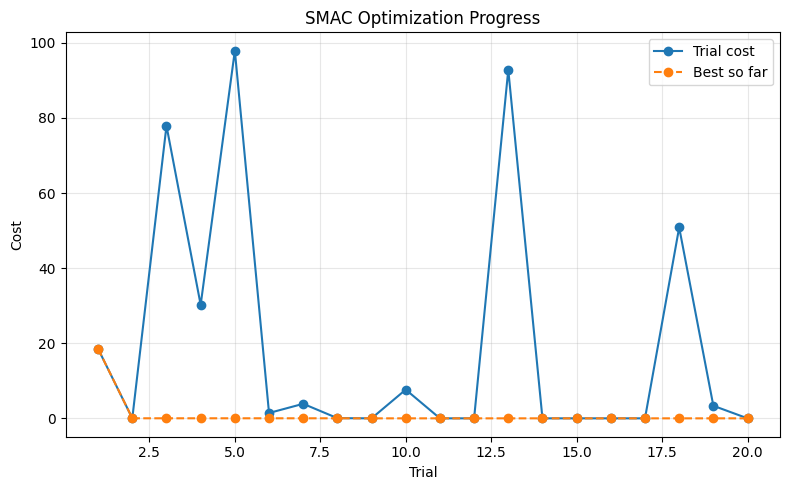

In [5]:
# Plot optimization progress and best-so-far curve
trials = sorted(rh.items(), key=lambda item: getattr(item[1], 'starttime', 0))
costs = np.array([trial_value.cost for _, trial_value in trials], dtype=float)
iterations = np.arange(1, len(costs) + 1)
if costs.size == 0:
    print('No trials to plot')
else:
    best_so_far = np.minimum.accumulate(costs)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(iterations, costs, marker='o', linestyle='-', label='Trial cost')
    ax.plot(iterations, best_so_far, marker='o', linestyle='--', label='Best so far')
    ax.set_title('SMAC Optimization Progress')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Cost')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

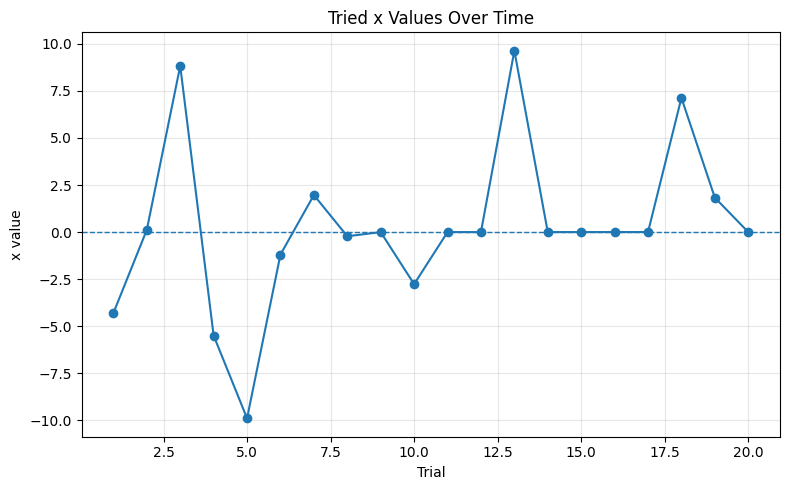

In [6]:
# Plot tried x values over time
if costs.size == 0:
    pass
else:
    x_values = np.array([rh.get_config(trial_key.config_id)['x'] for trial_key, _ in trials], dtype=float)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(iterations, x_values, marker='o', linestyle='-')
    ax.axhline(0, linestyle='--', linewidth=1)
    ax.set_title('Tried x Values Over Time')
    ax.set_xlabel('Trial')
    ax.set_ylabel('x value')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()